# Laboratório 11: Detecção e Tratamento Integrado de Outliers
**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Professor:** Luís Aramis

**Objetivo:** Atuar como um Auditor de Risco. Você vai aprender a diagnosticar anomalias univariadas usando Boxplots e a regra do IQR, tratar esses extremos de forma segura com `clip()` (Winsorization) e, por fim, utilizar Inteligência Artificial (Isolation Forest) para encontrar fraudes ocultas no cruzamento de múltiplas variáveis.

In [1]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Simulando um dataset de E-commerce com anomalias plantadas
np.random.seed(42)
n_linhas = 1000

df_risco = pd.DataFrame({
    'ID_Cliente': range(1, n_linhas + 1),
    'Idade_Conta': np.random.randint(10, 3650, n_linhas), # Dias
    'Receita': np.random.exponential(scale=500, size=n_linhas) + 50, 
    'Ticket_Medio': np.random.normal(150, 40, n_linhas)
})

# Plantando Outliers Univariados (O "Elon Musk")
df_risco.loc[990:995, 'Receita'] = 50000

# Plantando Outliers Multivariados (Fraudes Complexas)
# Contas recém-criadas (10 dias) com Ticket Médio absurdamente alto, 
# mas que não rompem o limite univariado isoladamente.
df_risco.loc[996:999, 'Idade_Conta'] = 10
df_risco.loc[996:999, 'Ticket_Medio'] = 500

display(df_risco.tail(15))

,ID_Cliente,Idade_Conta,Receita,Ticket_Medio
985,986,780,198.235480,123.520713
986,987,3387,1697.431486,167.035488
987,988,277,380.384186,150.765911
988,989,1994,869.929359,124.340524
989,990,1087,449.505625,169.514891
990,991,245,50000.000000,222.173924
991,992,398,50000.000000,142.363848
992,993,3047,50000.000000,178.790318
993,994,772,50000.000000,98.269082
994,995,1858,50000.000000,111.742545


## Parte 1: O Raio-X Visual (Boxplot)
Antes de fazermos matemática, precisamos enxergar o problema.
**Tarefa:** Plote um gráfico de caixa (`sns.boxplot`) para a coluna `Receita`. Identifique visualmente a caixa (onde estão 50% dos dados) e os pontos que representam os outliers (fora dos bigodes).

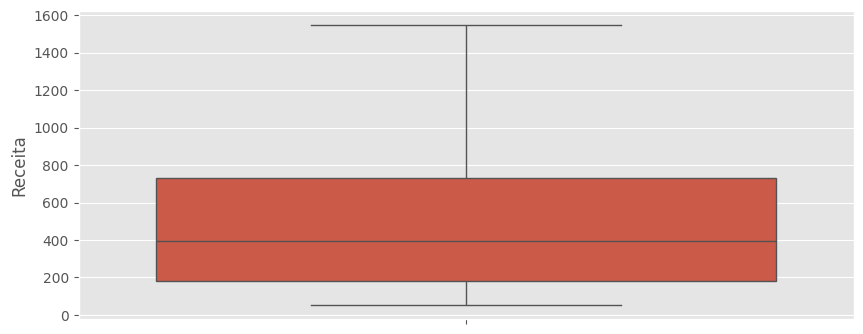

In [ ]:
# Plote o boxplot da coluna 'Receita' usando seaborn
plt.figure(figsize=(10, 4))
sns.boxplot(df_risco['Receita'],showfliers=False) #pra não mostrar o outlier 
plt.show()

## Parte 2: O Cálculo das Cercas (Regra do IQR)
O gráfico nos mostrou que temos valores extremos, mas onde exatamente começa a anomalia? 
A regra do Intervalo Interquartil (IQR) dita que:
1. Calculamos o Q1 (Percentil 25%) e o Q3 (Percentil 75%).
2. Subtraímos um do outro para achar o IQR (`Q3 - Q1`).
3. O Limite Superior é `Q3 + 1.5 * IQR`. Tudo acima disso é outlier matemático!

In [ ]:
# 1. Calcule Q1 e Q3 da coluna 'Receita' usando o método .quantile()
Q1 = df_risco['Receita'].quantile(0.25)
Q3 = df_risco['Receita'].quantile(0.75)
print('Q1',Q1, 'Q3', Q3)
# 2. Calcule o IQR
IQR = Q3-Q1 
print('IQR',IQR)
# 3. Defina o Limite Superior (Neste caso, não nos preocuparemos com o inferior pois não há receita negativa)
limite_superior = Q3 + 1.5 * IQR

print(f"O Limite Máximo Aceitável para a Receita é: R$ {limite_superior:.2f}")

Q1 182.92489260554248 Q3 729.1590646760884
IQR 546.2341720705459
O Limite Máximo Aceitável para a Receita é: R$ 1548.51


## Parte 3: A Cirurgia de Clipping
Se usarmos um `dropna()` e deletarmos os milionários da base, perderemos dados valiosos de `Idade_Conta` e `Ticket_Medio` que pertencem a eles. 

**A Solução:** Vamos usar a técnica de *Winsorization*.
**Sua Tarefa:** Use o método nativo `.clip()` do Pandas na coluna `Receita`. Defina o parâmetro `upper` como o `limite_superior` que você acabou de calcular. Salve isso em uma nova coluna chamada `Receita_Tratada`.

In [12]:
# Aplique o .clip() para amassar a cauda longa
df_risco['Receita_Tratada'] = df_risco['Receita'].clip(upper = limite_superior)

# Prove que funcionou verificando o novo valor máximo da coluna tratada
print("Novo Máximo:", df_risco['Receita_Tratada'].max())

Novo Máximo: 1548.5103227819072


## Parte 4: A Visão Multivariada
Nós resolvemos a Receita, mas e as fraudes ocultas? Existem clientes com contas recém-criadas gastando fortunas de uma só vez, o que burla o IQR isolado.

Vamos invocar o Scikit-Learn e a classe `IsolationForest` para auditar nossa base cruzando 3 colunas simultaneamente.

In [18]:
# 1. Isole as features que vão alimentar o modelo de IA
features = ['Idade_Conta', 'Receita_Tratada', 'Ticket_Medio']
X = df_risco[features]

# 2. Instancie o Detetive (Isolation Forest) esperando 1% de fraudes (contamination=0.01)
detector = IsolationForest(contamination=0.01,random_state=42)  #pode ser auto ao invés de 0.01 

detector

#Procura anomalias nessas 3 dimensões combinadas 
#Espera que 1% do dataset seja fraude / outlier >> o modelo usa isso para calibrar o threshold 

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [ ]:
# 3. Encaixe o modelo e faça as predições (fit_predict)
df_risco['Outlier_ML'] = detector.fit_predict(X)

## Retorna para cada linha:
#  1 → ponto normal
# -1 → outlier/anomalia detectada

# Faça um value_counts da nova coluna 'Outlier_ML' para ver quantos '-1' foram encontrados!
df_risco['Outlier_ML'].value_counts()

Outlier_ML
 1    990
-1     10
Name: count, dtype: int64

##### Isolation Forest: algoritmo de detecção de anomalias >> pontos anômalos são mais fáceis de isolar do que pontos normais.
Ele constrói árvores de decisão aleatórias e mede quantos cortes são necessários para isolar cada ponto. Outliers precisam de poucos cortes — ficam sozinhos rapidamente.


## Parte 5: O Desafio do Auditor (Para Casa)
O modelo Isolation Forest avaliou múltiplas dimensões e marcou os dados normais como `1` e as anomalias (fraudes) como `-1`.

Como analista de risco, seu diretor pediu um relatório comprovando o porquê o modelo barrou essas contas.

**Sua Tarefa (Missão de Casa):**
1. **Isolar:** Crie um filtro no `df_risco` para visualizar apenas os clientes classificados como `-1`.
2. **Comparar Perfis:** Use `df_risco.groupby('Outlier_ML').mean()` para comparar as médias de `Idade_Conta`, `Receita_Tratada` e `Ticket_Medio` dos clientes normais (1) vs anômalos (-1).
3. **Visão Executiva (Gráfico):** Crie um gráfico de dispersão (`sns.scatterplot`) colocando `Idade_Conta` no eixo X e `Ticket_Medio` no eixo Y. Use o parâmetro `hue='Outlier_ML'` para colorir os pontos e evidenciar visualmente as fraudes detectadas isoladas do comportamento padrão.
4. **Conclusão Auditorial:** Escreva qual é o padrão suspeito (o modus operandi) dessa fraude complexa.

In [ ]:
# 1. Isolar anomalias
df_anomalias= df_risco[df_risco['Outlier_ML']==-1]
df_normais = df_risco[df_risco['Outlier_ML']==1]
# 2. Comparar Médias (groupby)
media_anomalia = df_anomalias.mean()
media_normais = df_normais.mean()
media_geral = df_risco.mean()

,ID_Cliente,Idade_Conta,Receita,Ticket_Medio,Receita_Tratada,Outlier_ML
19,20,3390,1355.831382,238.420920,1355.831382,-1
23,24,3495,2006.826549,253.188374,1548.510323,-1
526,527,14,1497.780802,107.852703,1497.780802,-1
747,748,2992,1073.851776,275.509941,1073.851776,-1
861,862,3594,1408.104327,199.445229,1408.104327,-1
908,909,2940,1939.931556,47.506654,1548.510323,-1
996,997,10,179.437033,500.000000,179.437033,-1
997,998,10,169.157047,500.000000,169.157047,-1
998,999,10,522.063532,500.000000,522.063532,-1
999,1000,10,314.688716,500.000000,314.688716,-1


<Axes: xlabel='Idade_Conta', ylabel='Ticket_Medio'>

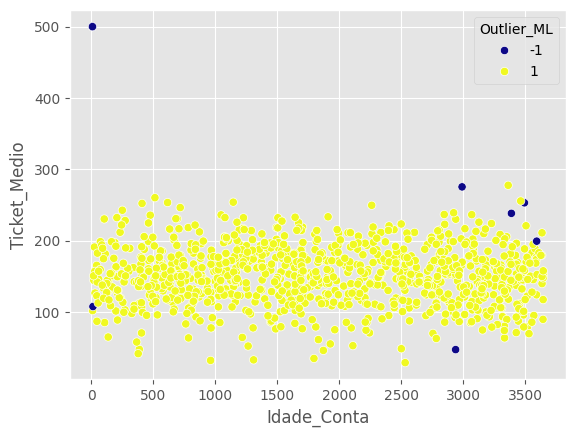

In [ ]:
# 3. Gráfico (Scatterplot de cruzamento Idade x Ticket com hue=Outlier_ML)
sns.scatterplot(df_risco, x= df_risco['Idade_Conta'], y = df_risco['Ticket_Medio'], hue = df_risco['Outlier_ML'], palette= "plasma")

# 4. Responda: Qual o padrão dessas contas barradas?qual é o padrão suspeito (o modus operandi) dessa fraude complexa.
#Observado: Idade da conta ou 0 ou acima de 2500. 
#Hipóteses: conta recém criada com ticker médio alto como conta criada para fraude E conta antiga com ticket médio alto como contas comprometidas. 


## Parte 6: Desafio com Dados Reais (Kaggle)
Até agora usamos dados simulados. Como seria aplicar isso no mundo real?

Vamos usar um dataset famoso do Kaggle: **Credit Card Fraud Detection**.
Ele contém transações de cartões de crédito, onde a classe positiva (fraude) é altamente desbalanceada.
Link do Dataset no Kaggle: [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

Baixaremos uma amostra ou usaremos um link raw disponível no GitHub.

In [30]:
# Carregando o dataset real de fraudes em cartão de crédito (Kaggle)
# Vamos usar um link direto (RAW), pode demorar alguns segundos devido ao tamanho do arquivo original.
url_kaggle = 'https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv'

# Lendo apenas as primeiras 50 mil linhas para não sobrecarregar a memória nesta aula
df_kaggle = pd.read_csv(url_kaggle, nrows=50000)

display(df_kaggle.head())
print("Formato dos dados: ", df_kaggle.shape)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Formato dos dados:  (50000, 31)


In [ ]:
#### PEGANDO DO KAGGLE:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv" #do kaggle 
# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path)

print("First 5 records:", df.head())

### Exercício 1: Explorando a Distribuição Visual
As variáveis `V1` a `V28` são o resultado de uma transformação PCA (para manter a privacidade). As únicas variáveis originais são `Time` e `Amount` (Valor da Transação).

**Sua Tarefa:**
1. Crie um Boxplot usando Seaborn para a variável `Amount`.
2. Analise: Pelo aspecto visual da cauda (pontos fora da caixa), o método do IQR (que corta os excessos) parece uma boa ideia para descobrir anomalias nesta coluna isolada?
Não, o IQR não parece apropriado para descobrir anomalias na coluna Amount isolada, porque há muitos outliers. 

<Axes: ylabel='Amount'>

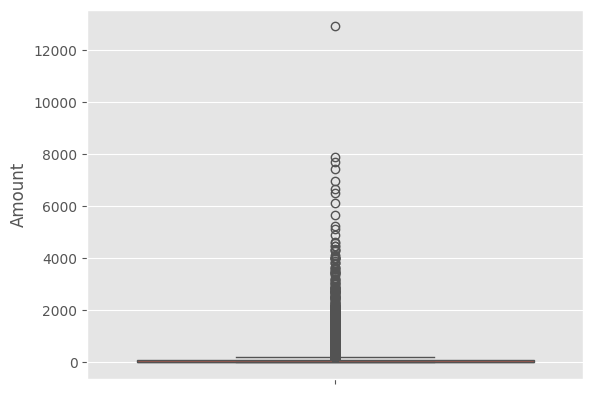

In [31]:
# Plote o Boxplot da coluna 'Amount'
sns.boxplot(df_kaggle['Amount'])


### Exercício 2: O Custo do Falso Positivo na Regra do IQR
Muitas fraudes podem ocorrer em transações de alto valor. Se usarmos a matemática do IQR cegamente, podemos estar punindo (falso positivo) clientes legítimos gastando muito. 
No dataset do Kaggle, a coluna `Class` vale 1 para fraude e 0 para transação normal.

**Sua Tarefa:**
1. Calcule o `limite_superior` para a coluna `Amount` usando a Regra do IQR (Q3 + 1.5 * IQR).
2. Descubra: Das transações que ficaram **acima** desse limite superior, quantas eram transações totalmente **Legítimas** (`Class == 0`)?

In [34]:
# 1. Calcule o Limite Superior
Q1 = df_kaggle['Amount'].quantile(0.25)
Q3 = df_kaggle['Amount'].quantile(0.75)
IQR = Q3 - Q1 
lim_sup = Q3 + 1.5* IQR
print('Q1', Q1, 'Q3', Q3, 'IQR', IQR, 'limite superior', lim_sup)

# 2. Filtre e conte as legítimas (Class == 0) que passaram do lim_sup
df_limite = df_kaggle[df_kaggle['Amount']> lim_sup]
df_limite['Class'].value_counts()

Q1 7.6274999999999995 Q3 85.25 IQR 77.6225 limite superior 201.68375


Class
0    5188
1      15
Name: count, dtype: int64

### Exercício 3: O Detetive de IA Multivariado (Isolation Forest)
Já que uma variável só não resolveu, vamos invocar o modelo de Machine Learning ensinando-o a ler 29 variáveis simultaneamente.

**Sua Tarefa:**
1. Isole a base de aprendizado ignorando as colunas `Class` (pois o detector é não-supervisionado) e `Time`: 
`X = df_kaggle.drop(columns=['Class', 'Time'])`
2. Instancie e treine o `IsolationForest` com `contamination=0.01` e `random_state=42`.
3. Salve o `.fit_predict(X)` em uma nova coluna `Outlier_ML` no dataset original.
4. Veja na prática a eficácia: Faça um cruzamento (`pd.crosstab`) da nossa predição `Outlier_ML` com a realidade `Class` do Kaggle!

In [41]:
df_aprendizado = df_kaggle.drop(columns=['Class','Time'])
df_aprendizado

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Outlier_ML
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,1
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,1
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,1
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-1.007648,0.722149,0.779027,-1.466661,0.298457,-0.263997,0.442429,0.400734,-0.591588,-1.191633,...,0.137489,0.171923,-0.205126,-0.650297,0.072522,1.391071,-0.167746,-0.019007,39.99,1
49996,-5.202399,2.077079,-3.905209,1.097967,-1.719915,-0.803272,-1.162430,2.679623,-0.640010,0.752146,...,-0.071897,0.396541,0.298550,-0.451037,-0.076617,-0.317780,0.508982,-0.144442,99.99,1
49997,-1.597980,-0.363988,2.114888,-1.101263,-0.291577,0.009897,0.456899,0.029229,0.712018,-0.304909,...,-0.161615,0.008125,-0.142336,0.078871,-0.016251,0.836074,0.302804,-0.022386,172.14,1
49998,-2.998734,2.323844,-2.419829,0.941745,-1.436231,-0.847601,-0.582896,1.965394,-0.846173,0.425120,...,0.201051,0.456424,-0.059220,0.040043,-0.435842,-0.391904,0.375636,-0.024394,89.99,1


In [50]:
detector_kaggle= IsolationForest(contamination=0.02,random_state=42) 
detector_kaggle

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [51]:
df_kaggle['Outlier_ML'] = detector_kaggle.fit_predict(df_aprendizado)
df_kaggle

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Outlier_ML
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,1
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,1
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,44296,-1.007648,0.722149,0.779027,-1.466661,0.298457,-0.263997,0.442429,0.400734,-0.591588,...,0.171923,-0.205126,-0.650297,0.072522,1.391071,-0.167746,-0.019007,39.99,0,1
49996,44297,-5.202399,2.077079,-3.905209,1.097967,-1.719915,-0.803272,-1.162430,2.679623,-0.640010,...,0.396541,0.298550,-0.451037,-0.076617,-0.317780,0.508982,-0.144442,99.99,0,1
49997,44298,-1.597980,-0.363988,2.114888,-1.101263,-0.291577,0.009897,0.456899,0.029229,0.712018,...,0.008125,-0.142336,0.078871,-0.016251,0.836074,0.302804,-0.022386,172.14,0,1
49998,44298,-2.998734,2.323844,-2.419829,0.941745,-1.436231,-0.847601,-0.582896,1.965394,-0.846173,...,0.456424,-0.059220,0.040043,-0.435842,-0.391904,0.375636,-0.024394,89.99,0,1


In [52]:
df_kaggle['Outlier_ML'].value_counts()

Outlier_ML
 1    49000
-1     1000
Name: count, dtype: int64

In [ ]:
# Mostre a confusão: COMPARA O PREDITO COM A REALIDADE 
display(pd.crosstab(df_kaggle['Outlier_ML'], df_kaggle['Class']))

#CLASS 0 1 É O REAL: (0 = NORMAL, 1 = FRAUDE )
#OUTLIER_ML É O QUE O MODELO DISSE (-1 FRAUDE, 1 NORMAL)

#-1, 1 = VERDADEIRO POSITIVO = FRAUDE QUE O MODELO PEGOU 
# -1 0 = FALSO POSITIVO = NORMAL QUE O MODELO ACUSOU ERRADO 
# 1 1 = FALSO NEGATIVO = FRAUDE REAL QUE O MODELO DEIXOU PASSAR 
# 1 0 VERDADEIRO NEGATIVO = NORMAL QUE O MODELO IGNOROU CORRETAMENTE 

## AUMENTO DE CONTAMINAION === ACUSAR MAIS INOCENTES 

Class,0,1
Outlier_ML,,
-1,874,126
1,48978,22
